🟢 DESAFIO 2: O Mistério do RH (Análise de Attrition)
Agora vamos trocar o chapéu de "Vendas" pelo de "Gestão de Pessoas".

O Cenário: A empresa quer entender o Turnover (rotatividade). Por que os funcionários pedem demissão? O Dataset: IBM HR Analytics (Fictício).

Base de dados: https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset

In [15]:
#Importando a base de dados que vamos usar
import pandas as pd

funcionarios = pd.read_csv("WA_Fn-UseC_-HR-Employee-Attrition.csv")
display(funcionarios)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,No,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,3,80,1,17,3,3,5,2,0,3
1466,39,No,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,1,80,1,9,5,3,7,7,1,7
1467,27,No,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,2,80,1,6,0,3,6,2,0,3
1468,49,No,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,4,80,0,17,3,2,9,6,0,8


In [16]:
##Garantindo que nao existe linhas vazias
display(funcionarios.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

None

In [21]:
##Aqui estamos trocando os valores de Yes para 1 e No para 0
print(funcionarios["Attrition"].unique())

funcionarios['Attrition'] = funcionarios['Attrition'].str.strip()

mapping = {'Yes': 1, 'No': 0}

funcionarios['Attrition'] = funcionarios['Attrition'].map(mapping)

display(funcionarios)

['Yes' 'No']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Numerico
0,41,1,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,80,0,8,0,1,6,4,0,5,1
1,49,0,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,80,1,10,3,3,10,7,1,7,0
2,37,1,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,80,0,7,3,3,0,0,0,0,1
3,33,0,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,80,0,8,3,3,8,7,3,0,0
4,27,0,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,80,1,6,3,3,2,2,2,2,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1465,36,0,Travel_Frequently,884,Research & Development,23,2,Medical,1,2061,...,80,1,17,3,3,5,2,0,3,0
1466,39,0,Travel_Rarely,613,Research & Development,6,1,Medical,1,2062,...,80,1,9,5,3,7,7,1,7,0
1467,27,0,Travel_Rarely,155,Research & Development,4,3,Life Sciences,1,2064,...,80,1,6,0,3,6,2,0,3,0
1468,49,0,Travel_Frequently,1023,Sales,2,3,Medical,1,2065,...,80,0,17,3,2,9,6,0,8,0


In [24]:
#calcular a taxa de saída
taxa_turnover = funcionarios['Attrition'].mean()

print(f"A taxa de rotatividade é: {taxa_turnover:.2%}")

A taxa de rotatividade é: 16.12%


           MonthlyIncome        Age
Attrition                          
0            6832.739659  37.561233
1            4787.092827  33.607595


C:\Users\João Luís\AppData\Local\Temp\ipykernel_39456\3730617490.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y='MonthlyIncome', data=funcionarios, palette='Set2')


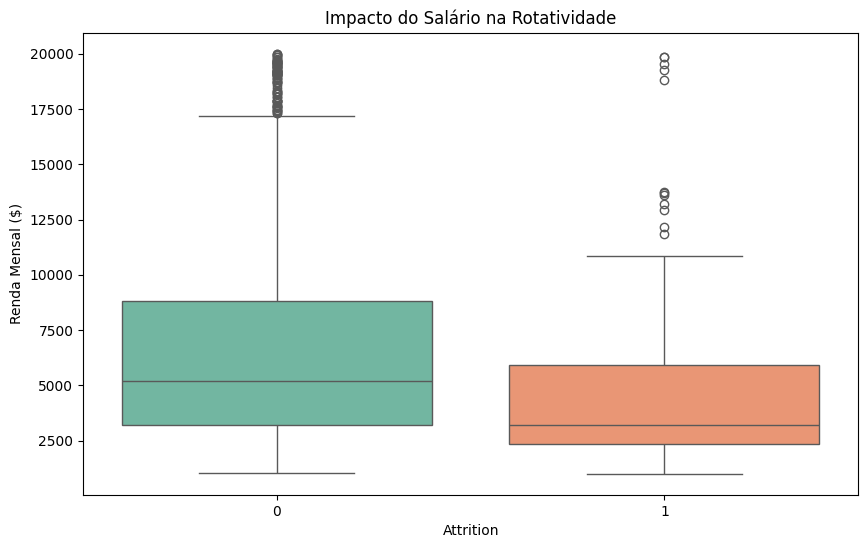

In [30]:
##Vamos comparar 2 grupos, "Quem sai é quem ganha menos
comparacao = funcionarios.groupby('Attrition')[['MonthlyIncome', 'Age']].mean()

print(comparacao)

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

sns.boxplot(x='Attrition', y='MonthlyIncome', data=funcionarios, palette='Set2')
plt.title("Impacto do Salário na Rotatividade")
plt.ylabel("Renda Mensal ($)")
plt.show()

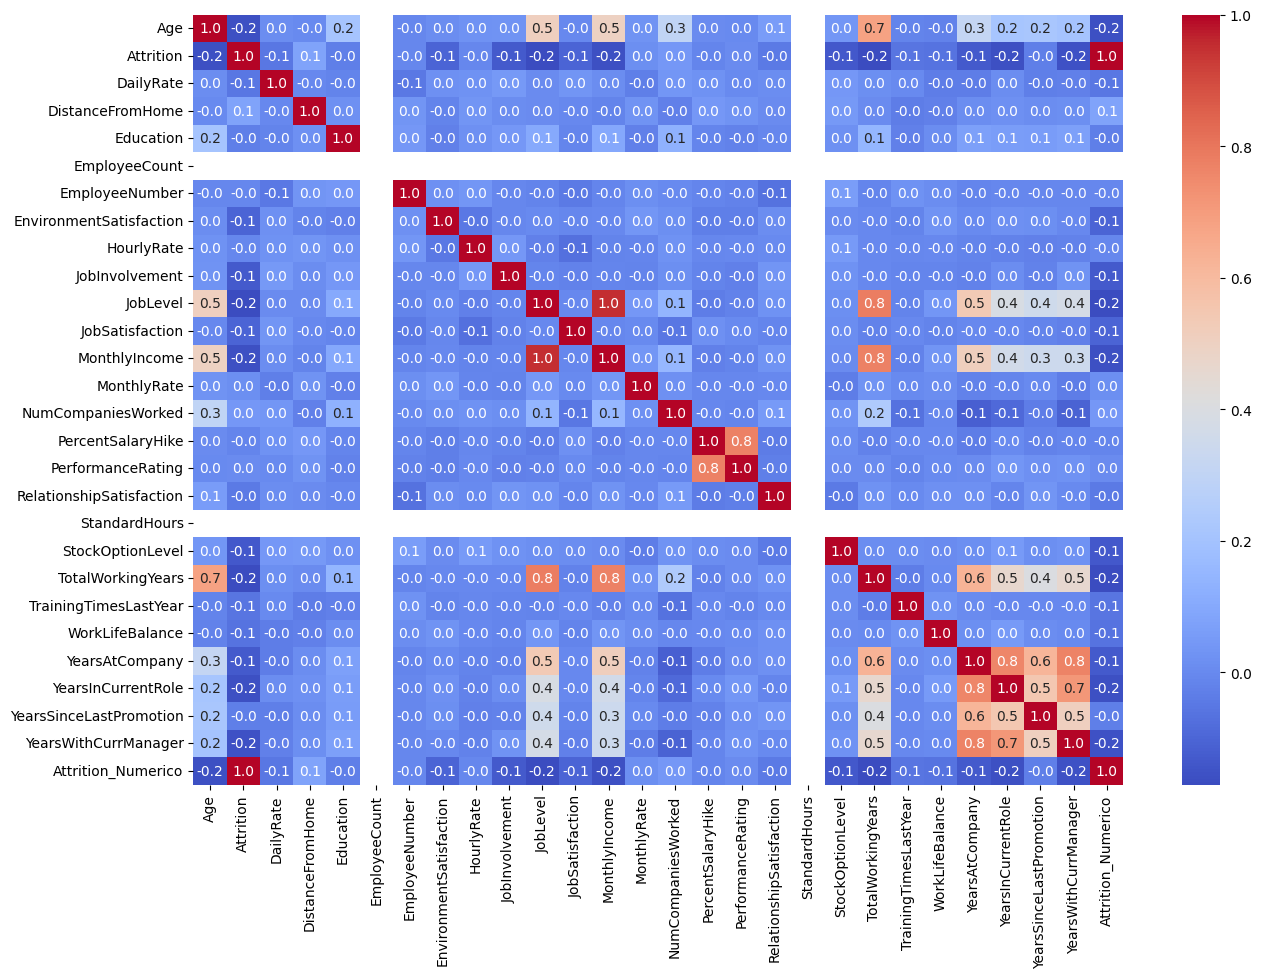

In [31]:
#ajustando o tamanho da figura, ela deve ser grande
plt.figure(figsize=(15,10))

#Agora apenas selecionando apenas as colunas numéricas para evitar erros
colunas_numericas = funcionarios.select_dtypes(include=['float64', 'int64'])

#calcular a correlação
correlacao = colunas_numericas.corr()

#gerar o Heatmap
sns.heatmap(correlacao, annot=True, fmt=".1f", cmap="coolwarm")

plt.show()

In [ ]:
##As variavei Age, TotalWorking, YearsAtCompany, YearsInCurrentRole, nos mostram que funcionarios mais novos 
# e com menos tempo de empresa tendem a pedir mais demissao, como os indicativos estão (-), quer dizer que quando mais sobre, a outra desce
#  ou seja mais tempo de empresa menos taxa de demissao (Zona da morte em quem está nos 2 primeiros anos de Empresa)
##StockOptionLevel, quase não saem, mostrando que é uma ferramenta poderosa de retenção